In [11]:
!pip install "dacite~=1.6.0" mlflow dagshub scikit-learn -q

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import dagshub
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
REPO_OWNER = 'ejoba22'
REPO_NAME = 'IEEE-CIS-Fraud-Detection'
EXPERIMENT_NAME = 'RandomForest_Training'

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

if mlflow.active_run() is not None:
    mlflow.end_run()

experiment = mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = experiment.experiment_id

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('MLflow experiment:', experiment.name)
print('MLflow experiment id:', EXPERIMENT_ID)

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

MLflow tracking URI: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow
MLflow experiment: RandomForest_Training
MLflow experiment id: 2


In [13]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min = df[col].min()
        c_max = df[col].max()
        if str(col_type).startswith('int'):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory reduced from {start_mem:.1f} MB to {end_mem:.1f} MB')
    return df


from pathlib import Path

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions/ieee-fraud-detection'),
    Path('/kaggle/input/ieee-fraud-detection')
]

DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if (path / 'train_transaction.csv').exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find IEEE-CIS data. '
        f'Tried: {[str(path) for path in DATA_DIR_CANDIDATES]}'
    )

print('Using data directory:', DATA_DIR)

train_transaction = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_transaction.csv'))
train_identity    = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_identity.csv'))

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
train = reduce_mem_usage(train)
print('Raw shape:', train.shape)

Using data directory: /kaggle/input/competitions/ieee-fraud-detection
Memory reduced from 2062.1 MB to 1203.2 MB
Memory reduced from 143.1 MB to 129.9 MB
Memory reduced from 1603.3 MB to 1603.3 MB
Raw shape: (590540, 434)


# Cleaning

In [14]:
train = train.sort_values('TransactionDT').reset_index(drop=True)
split_idx = int(len(train) * 0.8)
df_tr_raw  = train.iloc[:split_idx].copy()
df_val_raw = train.iloc[split_idx:].copy()

df_tr  = df_tr_raw.copy()
df_val = df_val_raw.copy()

print(f'Train: {len(df_tr):,} rows  |  Val: {len(df_val):,} rows')

RF_MISSING_THRESHOLD = 0.9
missing     = df_tr.isnull().mean()  
drop_cols   = missing[missing > RF_MISSING_THRESHOLD].index.tolist()
drop_cols  += ['TransactionID', 'TransactionDT']

df_tr  = df_tr.drop(columns=drop_cols,  errors='ignore')
df_val = df_val.drop(columns=drop_cols, errors='ignore')

cat_cols = df_tr.select_dtypes('object').columns.tolist()
category_maps = {}
for col in cat_cols:
    df_tr[col]  = df_tr[col].fillna('missing').astype(str)
    df_val[col] = df_val[col].fillna('missing').astype(str)
    unique_vals = df_tr[col].unique()
    category_maps[col] = {v: i for i, v in enumerate(unique_vals)}
    df_tr[col]  = df_tr[col].map(category_maps[col])
    df_val[col] = df_val[col].map(category_maps[col]).fillna(-1).astype('float32')

num_cols = [c for c in df_tr.select_dtypes(include=np.number).columns if c != 'isFraud']
medians  = df_tr[num_cols].median()
df_tr[num_cols]  = df_tr[num_cols].fillna(medians)
df_val[num_cols] = df_val[num_cols].fillna(medians)

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Cleaning'):
    mlflow.log_param('missing_threshold', RF_MISSING_THRESHOLD)
    mlflow.log_param('imputation',        'median')
    mlflow.log_param('cat_encoding',      'ordinal (unseen=-1)')
    mlflow.log_param('dropped_cols',      len(drop_cols))
    mlflow.log_param('remaining_cols',    df_tr.shape[1])

print(f'Shape after cleaning: {df_tr.shape}')
print(f'Remaining NaNs: {df_tr.isnull().sum().sum()}')

Train: 472,432 rows  |  Val: 118,108 rows
🏃 View run RandomForest_Cleaning at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/0f96507248f44a119f460d8ddd0de1ed
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
Shape after cleaning: (472432, 420)
Remaining NaNs: 0


# Feature Engineering

In [15]:
for df in [df_tr, df_val]:
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

for df_feat, df_raw in [(df_tr, df_tr_raw), (df_val, df_val_raw)]:
    df_feat['Transaction_hour']    = (df_raw['TransactionDT'] // 3600) % 24
    df_feat['Transaction_weekday'] = (df_raw['TransactionDT'] // 86400) % 7
    df_feat['is_night_hour']       = df_feat['Transaction_hour'].between(1, 6).astype(np.int8)
    df_feat['amt_rounded']         = (df_raw['TransactionAmt'] % 1 == 0).astype(np.int8)

new_features = ['TransactionAmt_log', 'Transaction_hour', 'Transaction_weekday',
                'is_night_hour', 'amt_rounded']

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Feature_Engineering'):
    mlflow.log_param('new_features', str(new_features))

print('Feature engineering done. New features:', new_features)

🏃 View run RandomForest_Feature_Engineering at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/945301665bf943f799414d23958bf031
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
Feature engineering done. New features: ['TransactionAmt_log', 'Transaction_hour', 'Transaction_weekday', 'is_night_hour', 'amt_rounded']


# Feature Selection

In [16]:
X_tr  = df_tr.drop(columns=['isFraud'])
y_tr  = df_tr['isFraud']
X_val = df_val.drop(columns=['isFraud'])
y_val = df_val['isFraud']

low_var = X_tr.var()[X_tr.var() < 0.01].index.tolist()
X_tr  = X_tr.drop(columns=low_var)
X_val = X_val.drop(columns=low_var)

corr_with_target = X_tr.corrwith(y_tr).abs()
low_corr = corr_with_target[corr_with_target < 0.02].index.tolist()
X_tr  = X_tr.drop(columns=low_corr)
X_val = X_val.drop(columns=low_corr)

print(f'After near-zero variance drop: removed {len(low_var)} cols')
print(f'After low-correlation drop:    removed {len(low_corr)} cols')
print(f'Final feature count: {X_tr.shape[1]}')

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Feature_Selection'):
    mlflow.log_param('method',             'near-zero variance + low correlation filter')
    mlflow.log_param('low_var_dropped',    len(low_var))
    mlflow.log_param('low_corr_dropped',   len(low_corr))
    mlflow.log_param('corr_threshold',     0.02)
    mlflow.log_param('final_features',     X_tr.shape[1])

After near-zero variance drop: removed 25 cols
After low-correlation drop:    removed 92 cols
Final feature count: 307
🏃 View run RandomForest_Feature_Selection at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/fc92845cf2e24d79af4ebeacd95beac0
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


# Training

In [17]:
# Underfit: very shallow trees 
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Training_underfit_depth3'):
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('n_estimators',  100)
    mlflow.log_param('max_depth',     3)
    mlflow.log_param('class_weight',  'balanced')
    mlflow.log_param('note',          'intentional underfit — depth too shallow')
    mlflow.log_metric('train_auc',    round(train_auc, 4))
    mlflow.log_metric('val_auc',      round(val_auc,   4))
    mlflow.log_metric('overfit_gap',  round(train_auc - val_auc, 4))

    print(f'[Underfit depth=3]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Underfit depth=3]  train=0.8268  val=0.8188  gap=0.0080
🏃 View run RandomForest_Training_underfit_depth3 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/f7d3123e1ce246788bf953bf9f5d2890
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


In [18]:
# Overfit: unlimited depth, few estimators 
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Training_overfit_depth_none'):
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('n_estimators',    100)
    mlflow.log_param('max_depth',       'None')
    mlflow.log_param('min_samples_leaf', 1)
    mlflow.log_param('class_weight',    'balanced')
    mlflow.log_param('note',            'intentional overfit — unlimited depth, min_samples_leaf=1')
    mlflow.log_metric('train_auc',      round(train_auc, 4))
    mlflow.log_metric('val_auc',        round(val_auc,   4))
    mlflow.log_metric('overfit_gap',    round(train_auc - val_auc, 4))

    print(f'[Overfit depth=None]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Overfit depth=None]  train=0.9979  val=0.8419  gap=0.1560
🏃 View run RandomForest_Training_overfit_depth_none at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/b577225f16224de791ae70815c6d5176
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


In [19]:
# Tuned: sweep over max_depth and min_samples_leaf

best_val_auc   = 0
best_depth     = None
best_min_leaf  = None

for max_depth in [10, 15, 20]:
    for min_samples_leaf in [10, 50]:
        run_name = f'RandomForest_Training_depth{max_depth}_leaf{min_samples_leaf}'
        with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
            model = RandomForestClassifier(
                n_estimators=200,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features='sqrt',
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
            model.fit(X_tr, y_tr)

            train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
            val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

            mlflow.log_param('n_estimators',     200)
            mlflow.log_param('max_depth',        max_depth)
            mlflow.log_param('min_samples_leaf', min_samples_leaf)
            mlflow.log_param('max_features',     'sqrt')
            mlflow.log_param('class_weight',     'balanced')
            mlflow.log_metric('train_auc',       round(train_auc, 4))
            mlflow.log_metric('val_auc',         round(val_auc,   4))
            mlflow.log_metric('overfit_gap',     round(train_auc - val_auc, 4))

            print(f'[depth={max_depth} leaf={min_samples_leaf}]  '
                  f'train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

            if val_auc > best_val_auc:
                best_val_auc  = val_auc
                best_depth    = max_depth
                best_min_leaf = min_samples_leaf

print(f'\nBest depth={best_depth}  leaf={best_min_leaf}  val_AUC={best_val_auc:.4f}')

[depth=10 leaf=10]  train=0.8851  val=0.8544  gap=0.0307
🏃 View run RandomForest_Training_depth10_leaf10 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/0f963649f8264513bf5488c49afa8c1b
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
[depth=10 leaf=50]  train=0.8809  val=0.8544  gap=0.0265
🏃 View run RandomForest_Training_depth10_leaf50 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/9131f252b9a54a13b38e4526334b0c43
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
[depth=15 leaf=10]  train=0.9317  val=0.8624  gap=0.0694
🏃 View run RandomForest_Training_depth15_leaf10 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/8de373ea34df4503a588f0919c65d9c1
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
[depth=15 leaf=50]  train=0.9141  val

In [20]:
# Cross-validation with best hyperparameters

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

N_CV_SPLITS = 5
cv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

cv_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_scores = cross_val_score(
    cv_model, X_tr, y_tr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

cv_mean = cv_scores.mean()
cv_std  = cv_scores.std()

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_CrossValidation'):
    mlflow.log_param('cv_strategy',      'TimeSeriesSplit')
    mlflow.log_param('n_splits',         N_CV_SPLITS)
    mlflow.log_param('n_estimators',     200)
    mlflow.log_param('max_depth',        best_depth)
    mlflow.log_param('min_samples_leaf', best_min_leaf)
    mlflow.log_param('max_features',     'sqrt')
    mlflow.log_metric('cv_auc_mean',     round(cv_mean, 4))
    mlflow.log_metric('cv_auc_std',      round(cv_std,  4))
    for i, s in enumerate(cv_scores):
        mlflow.log_metric(f'cv_fold_{i+1}_auc', round(s, 4))

print(f'CV AUC ({N_CV_SPLITS}-fold TimeSeriesSplit): {cv_mean:.4f} ± {cv_std:.4f}')
print(f'Individual folds: {[round(s, 4) for s in cv_scores]}')

🏃 View run RandomForest_CrossValidation at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/63884a12117a4d48ae4ba44b3c0ea119
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
CV AUC (5-fold TimeSeriesSplit): 0.8747 ± 0.0103
Individual folds: [np.float64(0.8646), np.float64(0.8667), np.float64(0.8827), np.float64(0.8688), np.float64(0.8909)]


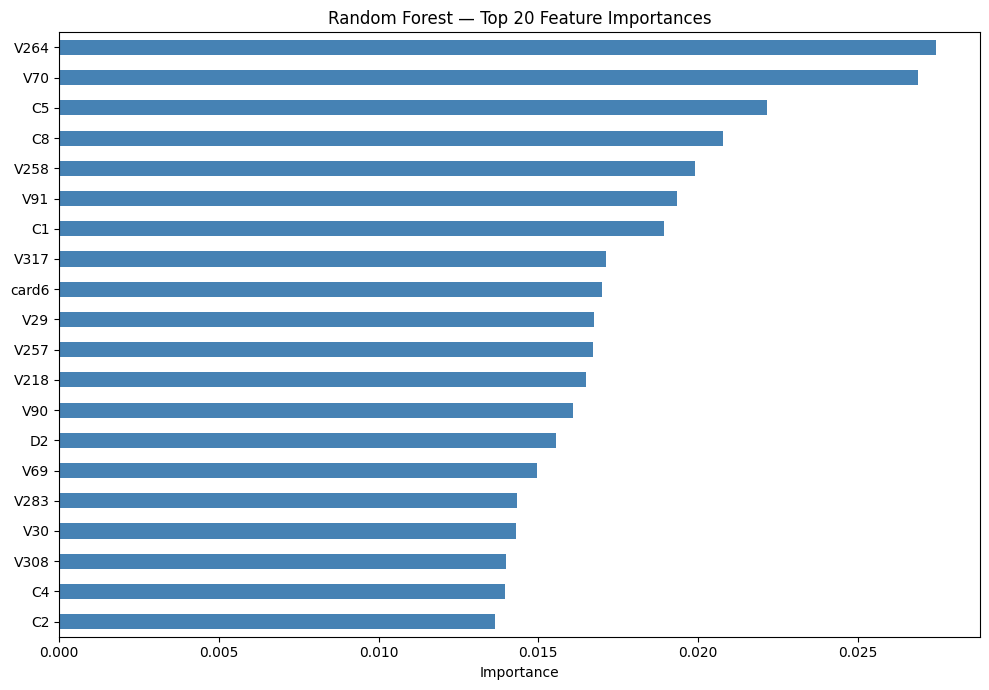

Top 10 features:
V264     0.027453
V70      0.026890
C5       0.022149
C8       0.020765
V258     0.019897
V91      0.019355
C1       0.018943
V317     0.017102
card6    0.017005
V29      0.016732
dtype: float64


In [21]:
# Feature importance plot from best tuned model 
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
best_model.fit(X_tr, y_tr)

importances = pd.Series(best_model.feature_importances_, index=X_tr.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top20.head(10))

In [22]:
# Build and register final Pipeline 

class RandomForestFraudPreprocessor(BaseEstimator, TransformerMixin):
    """Full preprocessing pipeline for Random Forest.
    Accepts raw (unprocessed) dataframe and returns a cleaned numpy array.
    """

    def __init__(self, missing_threshold=0.9, low_variance_threshold=0.01,
                 corr_threshold=0.02):
        self.missing_threshold    = missing_threshold
        self.low_variance_threshold = low_variance_threshold
        self.corr_threshold       = corr_threshold

    def _base_transform(self, X, y=None, fit=False):
        d = X.drop(columns=self.drop_cols_, errors='ignore').copy()
        d = d.drop(columns=['isFraud'], errors='ignore')

        # Feature engineering
        if 'TransactionAmt' in d.columns:
            d['TransactionAmt_log'] = np.log1p(d['TransactionAmt'])
        if 'TransactionDT' in X.columns:
            dt = X['TransactionDT']
            d['Transaction_hour']    = (dt // 3600) % 24
            d['Transaction_weekday'] = (dt // 86400) % 7
            d['is_night_hour']       = d['Transaction_hour'].between(1, 6).astype(np.int8)
        if 'TransactionAmt' in X.columns:
            d['amt_rounded'] = (X['TransactionAmt'] % 1 == 0).astype(np.int8)

        # Categorical encoding
        cat_cols = d.select_dtypes('object').columns.tolist()
        if fit:
            self.category_maps_ = {}
            for col in cat_cols:
                vals = d[col].fillna('missing').astype(str)
                self.category_maps_[col] = {v: i for i, v in enumerate(vals.unique())}
        for col in cat_cols:
            vals = d[col].fillna('missing').astype(str)
            d[col] = vals.map(self.category_maps_.get(col, {})).fillna(-1).astype('float32')

        # Downcast
        for col in d.select_dtypes('float64').columns:
            d[col] = d[col].astype('float32')
        for col in d.select_dtypes('int64').columns:
            d[col] = d[col].astype('int32')

        return d
        
    def fit(self, X, y=None):
        # Columns to drop (high missing + id cols)
        miss = X.isnull().mean()
        self.drop_cols_ = miss[miss > self.missing_threshold].index.tolist()
        self.drop_cols_ += ['TransactionID', 'TransactionDT']

        d = self._base_transform(X, y=y, fit=True)

        # Median imputation
        self.medians_ = d.median(numeric_only=True)
        d = d.fillna(self.medians_)

        # Near-zero variance filter
        self.low_var_cols_ = d.var()[d.var() < self.low_variance_threshold].index.tolist()
        d = d.drop(columns=self.low_var_cols_, errors='ignore')

        # Correlation filter (requires y)
        if y is not None:
            corr = d.corrwith(pd.Series(y, index=d.index)).abs()
            self.low_corr_cols_ = corr[corr < self.corr_threshold].index.tolist()
        else:
            self.low_corr_cols_ = []
        d = d.drop(columns=self.low_corr_cols_, errors='ignore')

        self.feature_columns_ = d.columns.tolist()
        return self

    def transform(self, X):
        d = self._base_transform(X, fit=False)
        d = d.fillna(self.medians_)
        d = d.drop(columns=self.low_var_cols_,  errors='ignore')
        d = d.drop(columns=self.low_corr_cols_, errors='ignore')
        d = d.reindex(columns=self.feature_columns_, fill_value=0)
        return d.values


# Sanity check
required_vars = ['best_depth', 'best_min_leaf', 'df_tr_raw', 'df_val_raw', 'EXPERIMENT_ID', 'X_tr']
missing_vars  = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'Run earlier cells first. Missing: {missing_vars}')

final_pipeline = Pipeline(steps=[
    ('preprocess', RandomForestFraudPreprocessor(
        missing_threshold=RF_MISSING_THRESHOLD,
        low_variance_threshold=0.01,
        corr_threshold=0.02
    )),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=best_depth,
        min_samples_leaf=best_min_leaf,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='RandomForest_Final_Pipeline_Register'):
    X_train_raw = df_tr_raw.drop(columns=['isFraud'])
    y_train_raw = df_tr_raw['isFraud']
    X_val_raw   = df_val_raw.drop(columns=['isFraud'])
    y_val_raw   = df_val_raw['isFraud']

    final_pipeline.fit(X_train_raw, y_train_raw)

    pipeline_feats = final_pipeline.named_steps['preprocess'].feature_columns_
    tuning_feats   = list(X_tr.columns)
    if pipeline_feats != tuning_feats:
        import warnings
        warnings.warn(
            f'Feature mismatch: pipeline has {len(pipeline_feats)} features, '
            f'tuning used {len(tuning_feats)}. '
            f'Differing cols: {set(pipeline_feats) ^ set(tuning_feats)}'
        )
    else:
        print(f'Feature check passed: {len(pipeline_feats)} features match tuning.')

    train_auc = roc_auc_score(y_train_raw, final_pipeline.predict_proba(X_train_raw)[:, 1])
    val_auc   = roc_auc_score(y_val_raw,   final_pipeline.predict_proba(X_val_raw)[:, 1])
    gap       = train_auc - val_auc

    mlflow.log_param('n_estimators',         200)
    mlflow.log_param('max_depth',            best_depth)
    mlflow.log_param('min_samples_leaf',     best_min_leaf)
    mlflow.log_param('max_features',         'sqrt')
    mlflow.log_param('class_weight',         'balanced')
    mlflow.log_param('missing_threshold',    RF_MISSING_THRESHOLD)
    mlflow.log_param('imputation',           'median')
    mlflow.log_param('cat_encoding',         'ordinal (unseen=-1)')
    mlflow.log_param('feature_engineering',  'log_amt, time features, is_night, amt_rounded')
    mlflow.log_param('feature_selection',    'near-zero variance + low correlation (0.02)')
    mlflow.log_metric('train_auc',           round(train_auc, 4))
    mlflow.log_metric('val_auc',             round(val_auc,   4))
    mlflow.log_metric('overfit_gap',         round(gap,       4))

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='random_forest_pipeline',
        registered_model_name='IEEE_CIS_RandomForest_Best'
    )

    print(f'Final pipeline — train={train_auc:.4f}  val={val_auc:.4f}  gap={gap:.4f}')
    print('Registered to Model Registry as: IEEE_CIS_RandomForest_Best')

Feature check passed: 307 features match tuning.


2026/05/05 11:44:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 11:44:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_CIS_RandomForest_Best'.
2026/05/05 11:44:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_CIS_RandomForest_Best, version 1
Created version '1' of model 'IEEE_CIS_RandomForest_Best'.


Final pipeline — train=0.9335  val=0.8737  gap=0.0598
Registered to Model Registry as: IEEE_CIS_RandomForest_Best
🏃 View run RandomForest_Final_Pipeline_Register at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/d5c0cfed5b0f487c859580f723591c96
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
